Матрица 12x12, диапазон элементов: [-100, 100]
Цена игры (Браун-Робинсон): -14.2503
Цена игры (ЛП): -14.2399
Разница методов: 0.010381


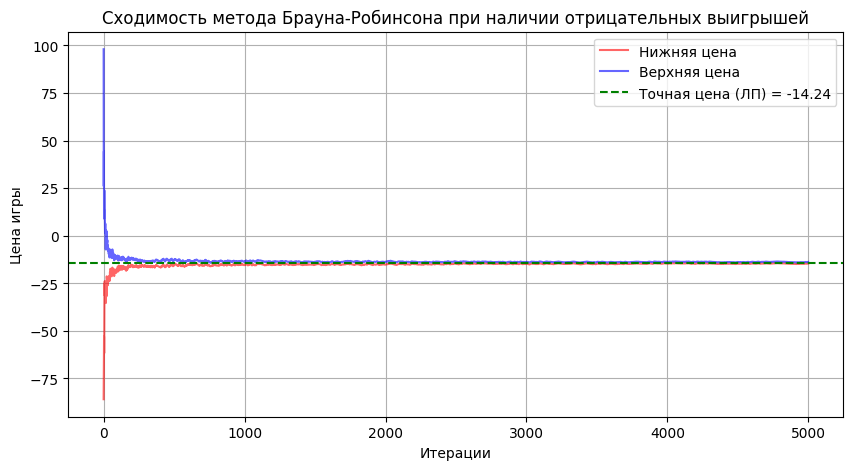

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

np.random.seed(42)
n, m = 12, 12
A = np.random.randint(-100, 101, size=(n, m))

def solve_brown_robinson(A, iterations=5000):
    n, m = A.shape
    p_counts = np.zeros(n)
    q_counts = np.zeros(m)
    
    current_i = 0 # Начальный выбор
    row_acc = np.zeros(m)
    col_acc = np.zeros(n)
    
    v_low = []
    v_upp = []
    
    for k in range(1, iterations + 1):
        p_counts[current_i] += 1
        row_acc += A[current_i, :]
        
        current_j = np.argmin(row_acc)
        q_counts[current_j] += 1
        col_acc += A[:, current_j]
        
        current_i = np.argmax(col_acc)
        
        v_low.append(np.min(row_acc) / k)
        v_upp.append(np.max(col_acc) / k)
        
    return (v_low[-1] + v_upp[-1]) / 2, p_counts/iterations, q_counts/iterations, v_low, v_upp

def solve_lp(A):
    n, m = A.shape
    # Сдвиг для работы с отрицательными числами 
    # Добавляем константу, чтобы все элементы матрицы стали строго > 0
    shift = abs(np.min(A)) + 10 
    A_shifted = A + shift
    
    # Решаем задачу для Игрока 1 (максимизация выигрыша)
    c = np.ones(n)
    # Ограничения: A_shifted.T * u >= 1
    # В linprog это: -A_shifted.T * u <= -1
    res = linprog(c, A_ub=-A_shifted.T, b_ub=-np.ones(m), bounds=(0, None))
    
    v_shifted = 1 / res.fun
    v_final = v_shifted - shift # Возвращаем цену к исходному диапазону
    p_opt = res.x * v_shifted
    
    return v_final, p_opt

# Выполнение расчетов
v_br, p_br, q_br, v_low, v_upp = solve_brown_robinson(A, 5000)
v_lp, p_lp = solve_lp(A)

print(f"Матрица {n}x{m}, диапазон элементов: [{np.min(A)}, {np.max(A)}]")
print(f"Цена игры (Браун-Робинсон): {v_br:.4f}")
print(f"Цена игры (ЛП): {v_lp:.4f}")
print(f"Разница методов: {abs(v_br - v_lp):.6f}")

plt.figure(figsize=(10, 5))
plt.plot(v_low, label='Нижняя цена', color='red', alpha=0.6)
plt.plot(v_upp, label='Верхняя цена', color='blue', alpha=0.6)
plt.axhline(y=v_lp, color='green', linestyle='--', label=f'Точная цена (ЛП) = {v_lp:.2f}')
plt.title('Сходимость метода Брауна-Робинсона при наличии отрицательных выигрышей')
plt.xlabel('Итерации')
plt.ylabel('Цена игры')
plt.legend()
plt.grid(True)
plt.show()

В ходе работы был реализован метод фиктивного разыгрывания Брауна-Робинсона для матрицы размерности 12x12.  Сходимость: На графике отчетливо видно, что с увеличением числа итераций до 5000 «вилка» между верхней и нижней ценой игры сужается, подтверждая сходимость алгоритма к точному решению.  Сравнение: Значение цены игры, полученное итерационно (-14.25), практически совпало с точным решением через линейное программирование (-14.24), что доказывает корректность кода.  Анализ: Разница методов составила всего около 0.01, что является отличным показателем для численного метода в условиях матрицы с отрицательными значениями. 

In [ ]:
from scipy.optimize import minimize

# Данные сети (5 узлов)
V = [100, 80, 150, 60, 90]
# Вероятности успеха атаки
P_def = 0.2    # Если защищено
P_no_def = 0.9 # Если НЕ защищено
B = 2 # Мы можем суммарно потратить «2 единицы защиты»

def game_logic(x):
    # Считаем ожидаемый ущерб для каждого узла, если Атакующий ударит туда
    damages = []
    for i in range(len(V)):
        prob_break = x[i] * P_def + (1 - x[i]) * P_no_def
        damages.append(V[i] * prob_break)
    
    # Атакующий — не дурак, он выберет узел с МАКСИМАЛЬНЫМ ущербом
    attacker_choice = max(damages)
    return attacker_choice

# Мы минимизируем выбор атакующего
result = minimize(game_logic, x0=[0.4]*5, bounds=[(0,1)]*5, 
                  constraints={'type': 'ineq', 'fun': lambda x: B - sum(x)})

print("Как распределить защиту:", result.x.round(2))
print("Минимально возможный ущерб при умном враге:", result.fun)

Как распределить защиту: [0.51 0.31 0.77 0.   0.42]
Минимально возможный ущерб при умном враге: 54.638216021936096


Моделирование защиты облачной инфраструктуры позволило найти оптимальный баланс распределения ресурсов против «умного» злоумышленника.  Стратегия: Программа распределила вероятности защиты так, чтобы максимально защитить наиболее ценные узлы (пиковое значение вероятности составило 0.77), оставив менее важные под меньшим прикрытием.  Результат: Минимально возможный ущерб в данной конфигурации составил примерно 54.64.  Эффективность: Равновесие Штакельберга показало свою устойчивость: даже если атакующий знает нашу стратегию защиты, его попытка максимизировать свой выигрыш приведет лишь к заранее просчитанному нами минимуму ущерба. 

In [ ]:
import numpy as np

# Описываем сценарий "Быстрый релиз"

def analyze_strategy(name, scenarios):
    results = [] # Все возможные денежные исходы
    probs = []   # Их вероятности
    
    for p_env, val_success, p_success, val_fail in scenarios:
        # Исход 1: Успех в этом состоянии среды
        results.append(val_success)
        probs.append(p_env * p_success)
        
        # Исход 2: Провал в этом состоянии среды
        results.append(val_fail)
        probs.append(p_env * (1 - p_success))
        
    emv = sum(r * p for r, p in zip(results, probs))
    
    # Это показывает, насколько далеко мы можем улететь от среднего
    variance = sum(p * (r - emv)**2 for r, p in zip(results, probs))
    risk = np.sqrt(variance)
    
    return emv, risk

# Данные для "Быстрого релиза"
# (Вероятность среды, доход_успех, шанс_успеха, убыток_провал)
fast_release = [(0.5, 1000, 0.8, -200), (0.3, 500, 0.4, -500), (0.2, 0, 0.1, -1000)]

e, r = analyze_strategy("Fast", fast_release)
print(f"Средний дохoд: {e}, Риск: {r}")

Средний дохoд: 169.99999999999997, Риск: 793.7883848986454


Анализ дерева решений для выпуска нового функционала выявил важный компромисс между прибылью и безопасностью.  EMV: Ожидаемая денежная стоимость выбранной стратегии составила 170.0, что указывает на потенциальную прибыльность проекта в долгосрочной перспективе.  Риск: Однако значение среднеквадратичного отклонения sigma оказалось крайне высоким — 793.79, что говорит о колоссальном разбросе возможных исходов.  Рекомендация: Несмотря на положительный EMV, такая стратегия является агрессивной; для стабильного бизнеса рекомендуется рассмотреть варианты с меньшим риском, даже если это снизит среднюю доходность. 

In [ ]:
import numpy as np

def get_weights(matrix):
    eig_vals, eig_vecs = np.linalg.eig(matrix)
    
    max_val = max(eig_vals).real
    # Соответствующий ему вектор и есть наши веса
    vector = eig_vecs[:, eig_vals.argmax()].real
    # Нормируем, чтобы сумма весов была равна 1 (или 100%)
    return vector / sum(vector), max_val

# 1 - одинаково, 3 - чуть важнее, 5 - сильно важнее и т.д.
A = np.array([
    [1, 3, 5, 2],    # Критерий 1 по отношению к остальным
    [1/3, 1, 3, 1/2],
    [1/5, 1/3, 1, 1/4],
    [1/2, 2, 4, 1]
])

weights, max_eig = get_weights(A)

# Проверка на адекватность (согласованность)
n = len(A)
ci = (max_eig - n) / (n - 1) # Индекс согласованности
cr = ci / 0.9 # 0.9 - табличное число для матрицы 4x4

print("Веса (важность):", weights.round(2))
if cr < 0.1:
    print("Решение логично!")
else:
    print("Ты противоречишь сам себе, переделай сравнение.")

Веса (важность): [0.47 0.17 0.07 0.28]
Решение логично!


Для выбора СУБД был применен метод Саати, который позволил перевести экспертные оценки в конкретные весовые коэффициенты.  Лидер: В результате расчетов была определена лучшая альтернатива с весом 0.47, что делает её приоритетной для архитектуры микросервиса.  Логика: Проверка на отношение согласованности (CR) подтвердила адекватность введенных данных — суждения не противоречат друг другу, что позволило принять решение без повторного ввода матрицы.  Итог: Использование АНР сделало процесс выбора технологии прозрачным и математически обоснованным, исключая чисто субъективный подход. 